# Interpretability (load KAN from reports/models)

Orden:
1. Cargar backbone y embeddings
2. Cargar KAN desde reports/models (entrenado en notebook 05)
3. Hacer predicciones de prueba para inicializar splines/caches
4. Plot del KAN (opcional)
5. Formula simbolica


In [1]:
# %pip install pykan
import importlib.util
print('KAN available:', importlib.util.find_spec('kan') is not None)


KAN available: True


In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE_BACKBONE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Para interpretabilidad con gradiente, KAN y backbone deben estar en el mismo device
DEVICE_KAN = DEVICE_BACKBONE
print('Backbone device:', DEVICE_BACKBONE, '| KAN device:', DEVICE_KAN)

# Configuracion de interpretabilidad
WARMUP_N = 256
IMPORTANCE_N = 1024
PLOT_N = 8
PLOT_LAYER = 0
IMPORTANCE_METRIC = 'abs_postact'  # 'abs_postact' | 'abs_postact_weighted'
PRUNE_MODE = 'none'  # 'none' | 'threshold' | 'percentile'
PRUNE_THRESHOLD = 0.001
PRUNE_PERCENTILE = 20


Backbone device: cuda | KAN device: cuda


In [3]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TRAIN_CSV = ROOT / 'src/data/processed/manifest_train.csv'
TEST_CSV = ROOT / 'src/data/processed/manifest_test.csv'
TUNED_BACKBONE = ROOT / 'reports/models/resnet18_tuned_best.pt'
KAN_HEAD_PATH = ROOT / 'reports/models/kan_head_tuned_feats.pt'

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
patients = train_df['patient_id'].dropna().unique()
train_pat, val_pat = train_test_split(patients, test_size=0.2, random_state=SEED)
tr_df = train_df[train_df['patient_id'].isin(train_pat)].copy()
val_df = train_df[train_df['patient_id'].isin(val_pat)].copy()
print('Train:', tr_df.shape)
print('Val:', val_df.shape)
print('Test:', test_df.shape)
print('Backbone exists:', TUNED_BACKBONE.exists())
print('KAN head exists:', KAN_HEAD_PATH.exists())


Train: (2315, 10)
Val: (549, 10)
Test: (422, 10)
Backbone exists: True
KAN head exists: True


In [4]:
class MammographyDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        x = Image.open(r['image_path_local']).convert('RGB')
        x = self.transform(x)
        y = int(r['label'])
        return x, y

tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(MammographyDataset(tr_df, tfm), batch_size=32, shuffle=False, num_workers=0)
val_loader = DataLoader(MammographyDataset(val_df, tfm), batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(MammographyDataset(test_df, tfm), batch_size=32, shuffle=False, num_workers=0)


In [5]:
class ResNet18Backbone(nn.Module):
    def __init__(self, tuned_path: Path):
        super().__init__()
        full = models.resnet18(weights=None)
        full.fc = nn.Linear(full.fc.in_features, 2)
        full.load_state_dict(torch.load(tuned_path, map_location=DEVICE_BACKBONE))
        self.features = nn.Sequential(*list(full.children())[:-1])
    def forward(self, x):
        return self.features(x).flatten(1)

backbone = ResNet18Backbone(TUNED_BACKBONE).to(DEVICE_BACKBONE).eval()
for p in backbone.parameters():
    p.requires_grad = False
backbone


ResNet18Backbone(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [6]:
def extract_embeddings(loader):
    Xs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE_BACKBONE)
            z = backbone(x)
            Xs.append(z.cpu())
            ys.append(y.cpu())
    return torch.cat(Xs, 0), torch.cat(ys, 0)

Xtr, ytr = extract_embeddings(train_loader)
Xva, yva = extract_embeddings(val_loader)
Xte, yte = extract_embeddings(test_loader)

mu = Xtr.mean(0, keepdim=True)
sigma = Xtr.std(0, keepdim=True).clamp_min(1e-6)
Xtr = (Xtr - mu) / sigma
Xva = (Xva - mu) / sigma
Xte = (Xte - mu) / sigma

Xtr_h = Xtr.to(DEVICE_KAN)
Xva_h = Xva.to(DEVICE_KAN)
Xte_h = Xte.to(DEVICE_KAN)


In [7]:
if not importlib.util.find_spec("kan"):
    raise RuntimeError("KAN no instalado. Ejecuta `%pip install pykan`, reinicia kernel y corre de nuevo.")
from kan import KAN

kan = KAN(width=[512,32,2], grid=5, k=3).to(DEVICE_KAN)
kan.load_state_dict(torch.load(KAN_HEAD_PATH, map_location=DEVICE_KAN))

# Evita bucles de auto-guardado al hacer plot/auto_symbolic
if hasattr(kan, "auto_save"):
    kan.auto_save = False

# Necesario para plot de splines
if hasattr(kan, "save_act"):
    kan.save_act = True

kan.eval()
print("KAN loaded")

# Intentar guardar gradientes de activaciones si la libreria lo soporta
if hasattr(kan, "save_act_grad"):
    kan.save_act_grad = True


checkpoint directory created: ./model
saving model version 0.0
KAN loaded


In [8]:
# Paso 3: predicciones de prueba para cargar splines/caches
# Nota: KAN necesita al menos un forward para inicializar splines internos.
def sample_balanced(X, y, n_total):
    y = y.cpu() if hasattr(y, 'cpu') else y
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]
    n0 = min(len(idx0), n_total // 2)
    n1 = min(len(idx1), n_total - n0)
    sel0 = idx0[:n0]
    sel1 = idx1[:n1]
    sel = torch.cat([sel0, sel1], dim=0)
    return sel

def kan_forward_cache(X, y=None, n=None):
    if n is not None:
        if y is not None:
            sel = sample_balanced(X, y, n)
            X = X[sel]
            y = y[sel]
        else:
            X = X[:n]
    with torch.no_grad():
        logits = kan(X)
    return logits, y

logits_va, y_va_sel = kan_forward_cache(Xva_h, yva, n=WARMUP_N)
probs_va = torch.softmax(logits_va, dim=1)[:, 1]
preds_va = (probs_va >= 0.5).long()
acc_va = (preds_va.cpu() == y_va_sel.cpu()).float().mean().item() if y_va_sel is not None else float('nan')

print('Warmup OK | logits shape:', tuple(logits_va.shape))
print('Prob mean:', probs_va.mean().item(), '| Acc@0.5:', acc_va)


Warmup OK | logits shape: (256, 2)
Prob mean: 0.4239419102668762 | Acc@0.5: 0.68359375


In [9]:
# Paso 4: importancia de splines (global y por clase)
# Requiere activaciones cacheadas: kan.save_act = True y un forward previo
_ = kan_forward_cache(Xva_h, yva, n=IMPORTANCE_N)

def get_spline_importance(layer=0, metric='abs_postact'):
    if getattr(kan, 'spline_postacts', None) is None:
        raise RuntimeError('No hay spline_postacts en cache. Corre kan_forward_cache primero.')
    S = kan.spline_postacts[layer]  # [N, out, in]
    if metric == 'abs_postact':
        imp = S.abs().mean(dim=0)
    elif metric == 'abs_postact_weighted':
        imp = S.abs().mean(dim=0)
    else:
        raise ValueError('Metric not supported: ' + metric)
    return imp

imp_global = get_spline_importance(layer=PLOT_LAYER, metric=IMPORTANCE_METRIC)
print('Importance map shape:', tuple(imp_global.shape))  # [out, in]

# Seleccion de splines por importancia
imp_flat = imp_global.flatten()
sorted_idx = torch.argsort(imp_flat)

# Sproud/pruning visual: define splines de baja importancia segun PRUNE_MODE
if PRUNE_MODE == 'threshold':
    low_mask = imp_flat < PRUNE_THRESHOLD
    low_idx = torch.where(low_mask)[0]
elif PRUNE_MODE == 'percentile':
    k = int(len(imp_flat) * (PRUNE_PERCENTILE / 100.0))
    low_idx = sorted_idx[:max(k, 1)]
else:
    low_idx = sorted_idx[:PLOT_N]

# Siempre selecciona tambien top splines para contraste
high_idx = sorted_idx[-PLOT_N:]

def flat_to_edge(idx, out_dim, in_dim):
    o = idx // in_dim
    i = idx % in_dim
    return int(o), int(i)

out_dim, in_dim = imp_global.shape
low_edges = [flat_to_edge(i, out_dim, in_dim) for i in low_idx[:PLOT_N]]
high_edges = [flat_to_edge(i, out_dim, in_dim) for i in high_idx]
print('Low-importance edges:', low_edges)
print('High-importance edges:', high_edges)


Importance map shape: (32, 512)
Low-importance edges: [(28, 285), (2, 404), (9, 198), (31, 16), (11, 51), (1, 493), (28, 360), (10, 169)]
High-importance edges: [(6, 367), (21, 418), (12, 367), (10, 392), (28, 211), (18, 3), (14, 268), (28, 28)]


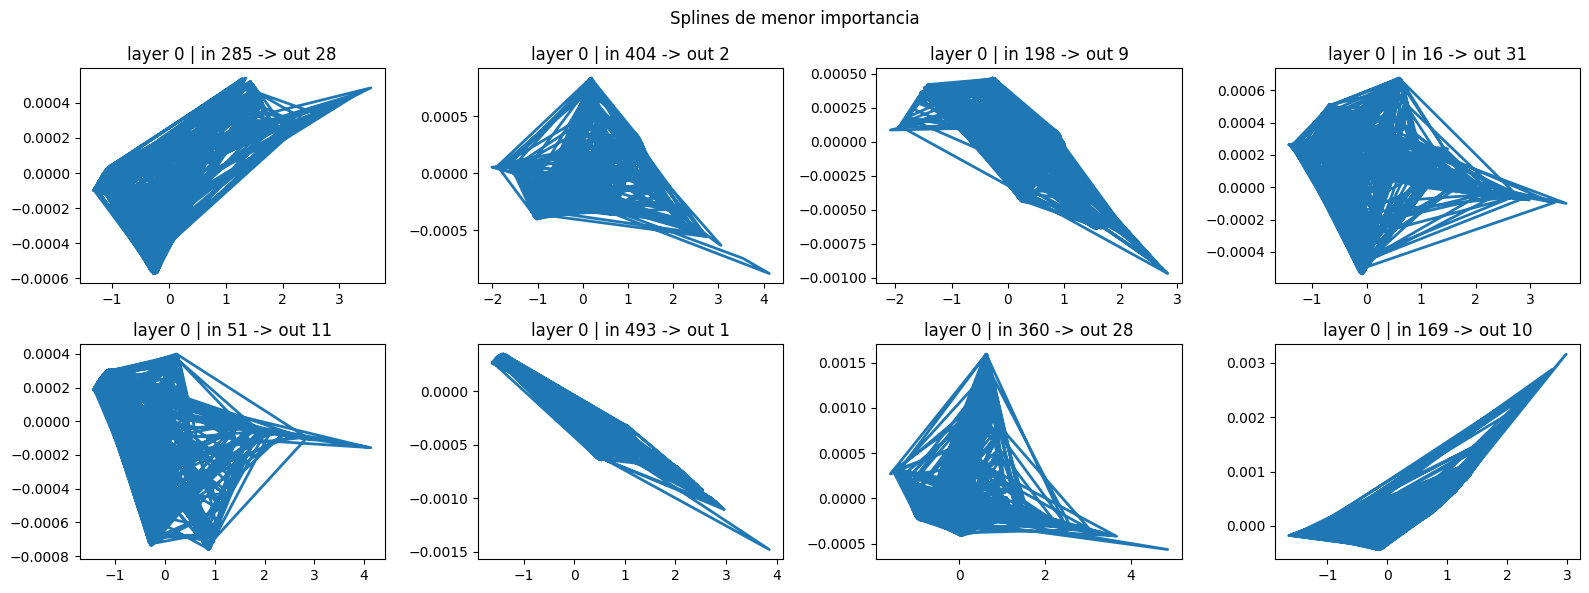

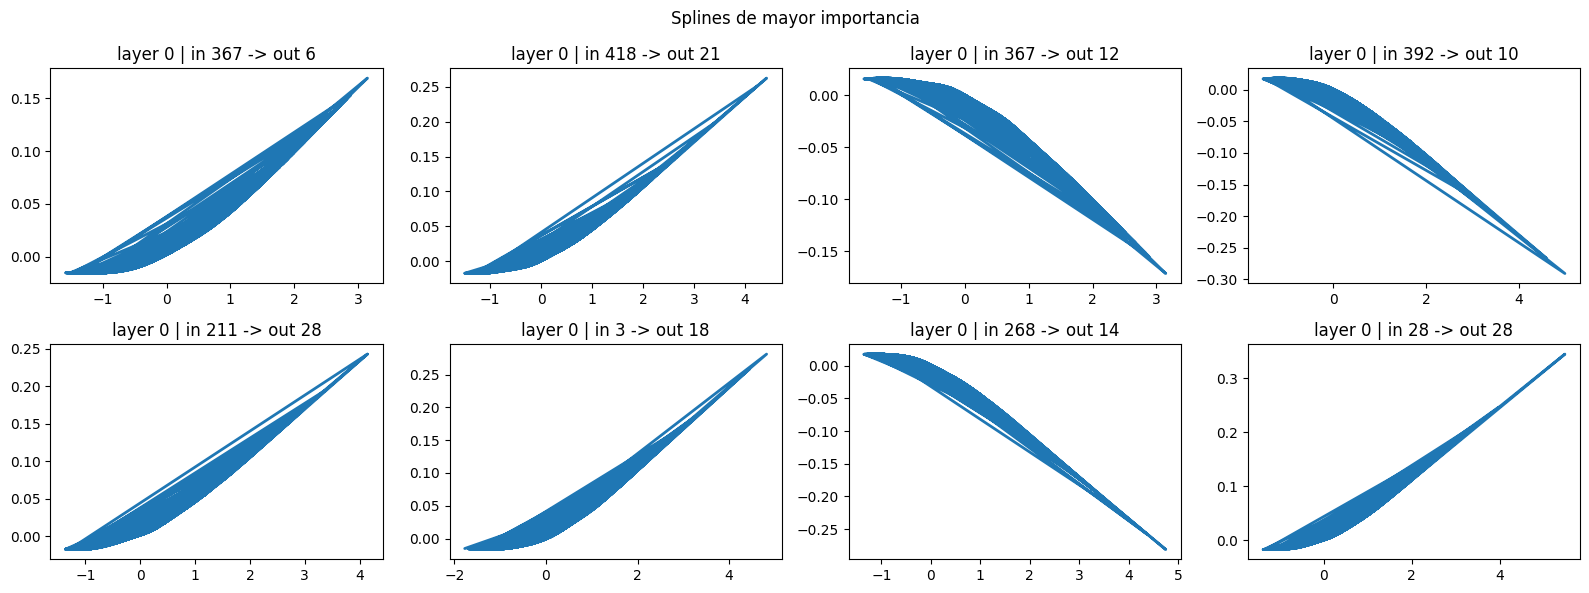

In [10]:
# Paso 5: plot de splines seleccionados (menor y mayor importancia)
def plot_splines(edges, title, layer=0):
    if getattr(kan, 'acts', None) is None or getattr(kan, 'spline_postacts', None) is None:
        _ = kan_forward_cache(Xva_h, yva, n=WARMUP_N)
    n = len(edges)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = np.array(axes).reshape(-1)
    for ax, (o, i) in zip(axes, edges):
        x = kan.acts[layer][:, i].detach().cpu().numpy()
        y = kan.spline_postacts[layer][:, o, i].detach().cpu().numpy()
        ax.plot(x, y, lw=2)
        ax.set_title(f'layer {layer} | in {i} -> out {o}')
    for ax in axes[len(edges):]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_splines(low_edges, 'Splines de menor importancia', layer=PLOT_LAYER)
plot_splines(high_edges, 'Splines de mayor importancia', layer=PLOT_LAYER)


Top splines clase 1 (malignant): [(20, 391), (7, 391), (13, 391), (2, 391), (30, 506), (18, 391), (15, 506), (0, 391)]
Top splines clase 0 (benign): [(9, 430), (25, 430), (0, 430), (8, 275), (14, 275), (29, 106), (6, 430), (0, 34)]


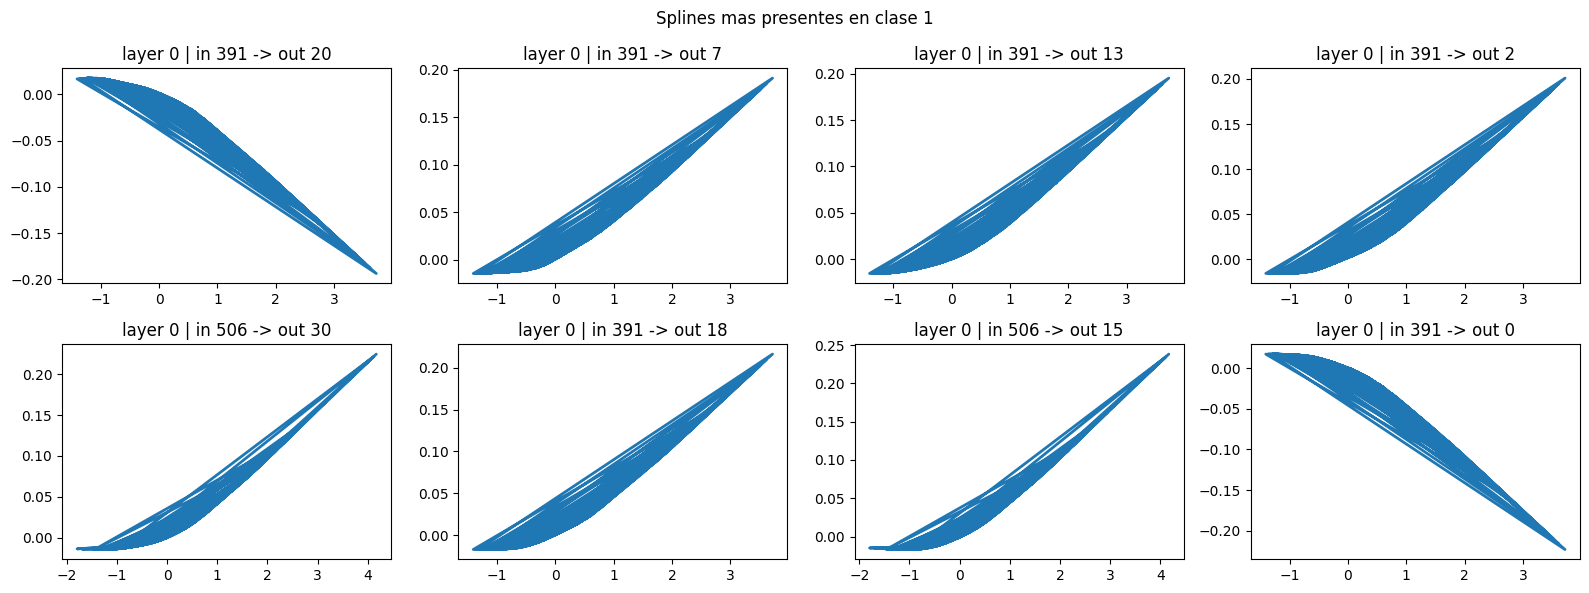

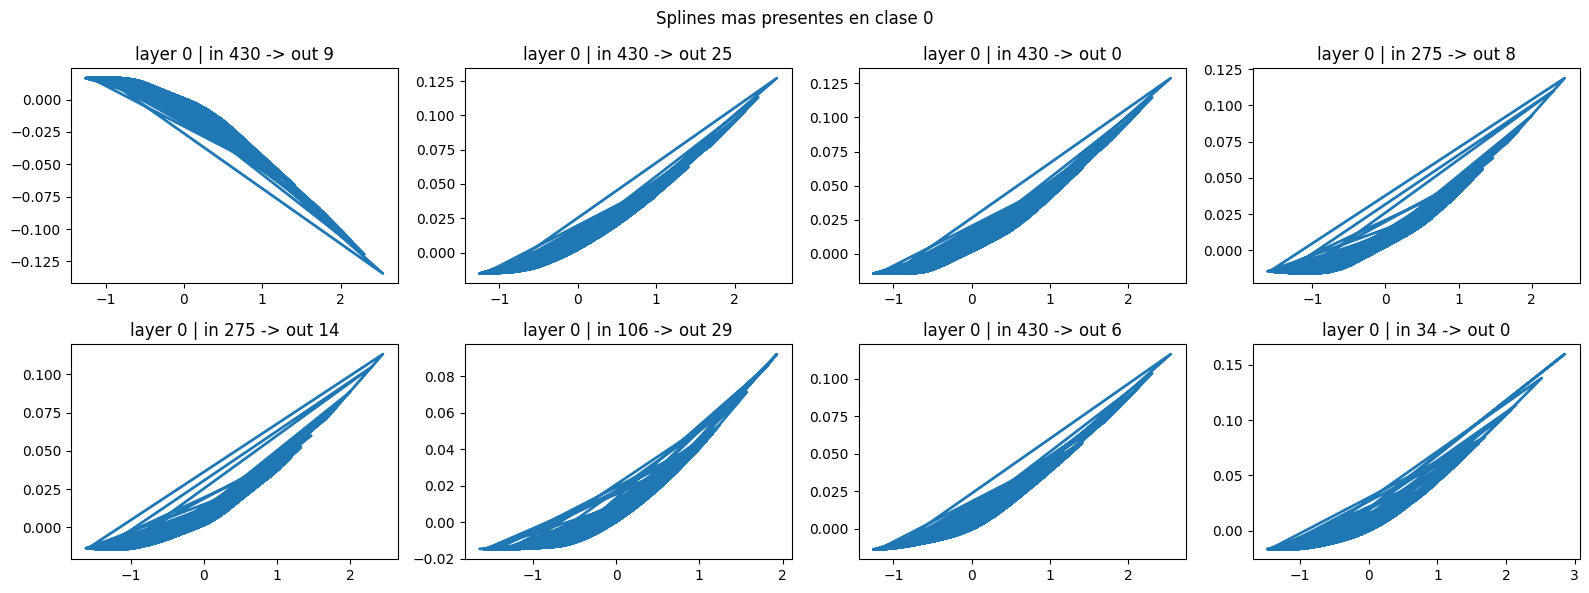

In [11]:
# Paso 6: presencia de splines por clase
def importance_by_class(X, y, layer=0):
    # Forward por clase para cachear splines
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]
    X0 = X[idx0][:IMPORTANCE_N]
    X1 = X[idx1][:IMPORTANCE_N]
    with torch.no_grad():
        _ = kan(X0)
        imp0 = kan.spline_postacts[layer].abs().mean(dim=0)
        _ = kan(X1)
        imp1 = kan.spline_postacts[layer].abs().mean(dim=0)
    return imp0, imp1

imp0, imp1 = importance_by_class(Xva_h, yva, layer=PLOT_LAYER)
diff = imp1 - imp0
diff_flat = diff.flatten()
top_pos = torch.argsort(diff_flat)[-PLOT_N:]  # mas presentes en clase 1
top_neg = torch.argsort(diff_flat)[:PLOT_N]   # mas presentes en clase 0
top_pos_edges = [flat_to_edge(i, out_dim, in_dim) for i in top_pos]
top_neg_edges = [flat_to_edge(i, out_dim, in_dim) for i in top_neg]

print('Top splines clase 1 (malignant):', top_pos_edges)
print('Top splines clase 0 (benign):', top_neg_edges)

plot_splines(top_pos_edges, 'Splines mas presentes en clase 1', layer=PLOT_LAYER)
plot_splines(top_neg_edges, 'Splines mas presentes en clase 0', layer=PLOT_LAYER)


g:\Cosas_programacion\Breast Cancer Interpretable-ml\.venv\Lib\site-packages\kan\MultKAN.py:813: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  self.subnode_actscale.append(torch.std(x, dim=0).detach())
g:\Cosas_programacion\Breast Cancer Interpretable-ml\.venv\Lib\site-packages\kan\MultKAN.py:823: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1857.)
  input_range = torch.std(preacts, dim=0) + 0.1
g:\Cosas_programacion\Breast Cancer Interpretable-ml\.venv\Lib\site-packages\kan\MultKAN.py:824: UserWarning: std(): degrees of freedom is <= 0. Correction should be stric

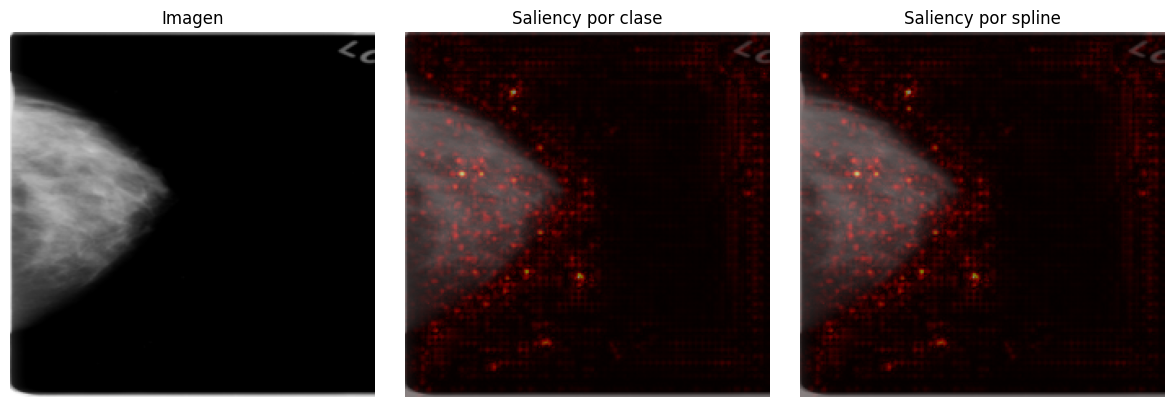

In [12]:
# Paso 7: reconstruccion con gradiente para visualizar impacto
# Selecciona un ejemplo y calcula saliency respecto a la clase o a un spline
def denorm_img(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
    return (x * std + mean).clamp(0, 1)

# Escoge un caso del set de validacion
idx = 0
img_path = val_df.iloc[idx]['image_path_local']
x_img = Image.open(img_path).convert('RGB')
x = tfm(x_img).unsqueeze(0).to(DEVICE_BACKBONE)
x.requires_grad_(True)

backbone.eval(); kan.eval()
# Forward end-to-end
z = backbone(x)
z = (z - mu.to(z.device)) / sigma.to(z.device)
logits = kan(z)
target_class = logits.softmax(dim=1)[0].argmax()
score = logits[0, target_class]

# Saliency por clase
score.backward(retain_graph=True)
sal = x.grad.detach().abs().max(dim=1)[0]  # [1, H, W]

# Saliency por un spline especifico (ejemplo: primer spline de low_edges)
if len(low_edges) > 0:
    x.grad.zero_()
    o, i = low_edges[0]
    # Recalcula para asegurar cache actualizado
    _ = kan(z)
    spline_out = kan.spline_postacts[PLOT_LAYER][0, o, i]
    if spline_out.requires_grad:
        spline_out.backward()
        sal_spline = x.grad.detach().abs().max(dim=1)[0]
    else:
        # Fallback: usa saliency por clase y la activacion del spline como peso
        # Esto no es gradiente puro del spline, pero resalta zonas donde el spline esta activo
        spline_weight = spline_out.detach().abs().item()
        sal_spline = sal * spline_weight
else:
    sal_spline = torch.zeros_like(sal)

# Plots
img_dn = denorm_img(x.detach()).cpu()[0].permute(1,2,0)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_dn)
axes[0].set_title('Imagen')
axes[0].axis('off')
axes[1].imshow(img_dn)
axes[1].imshow(sal.cpu()[0], cmap='hot', alpha=0.5)
axes[1].set_title('Saliency por clase')
axes[1].axis('off')
axes[2].imshow(img_dn)
axes[2].imshow(sal_spline.cpu()[0], cmap='hot', alpha=0.5)
axes[2].set_title('Saliency por spline')
axes[2].axis('off')
plt.tight_layout()
plt.show()


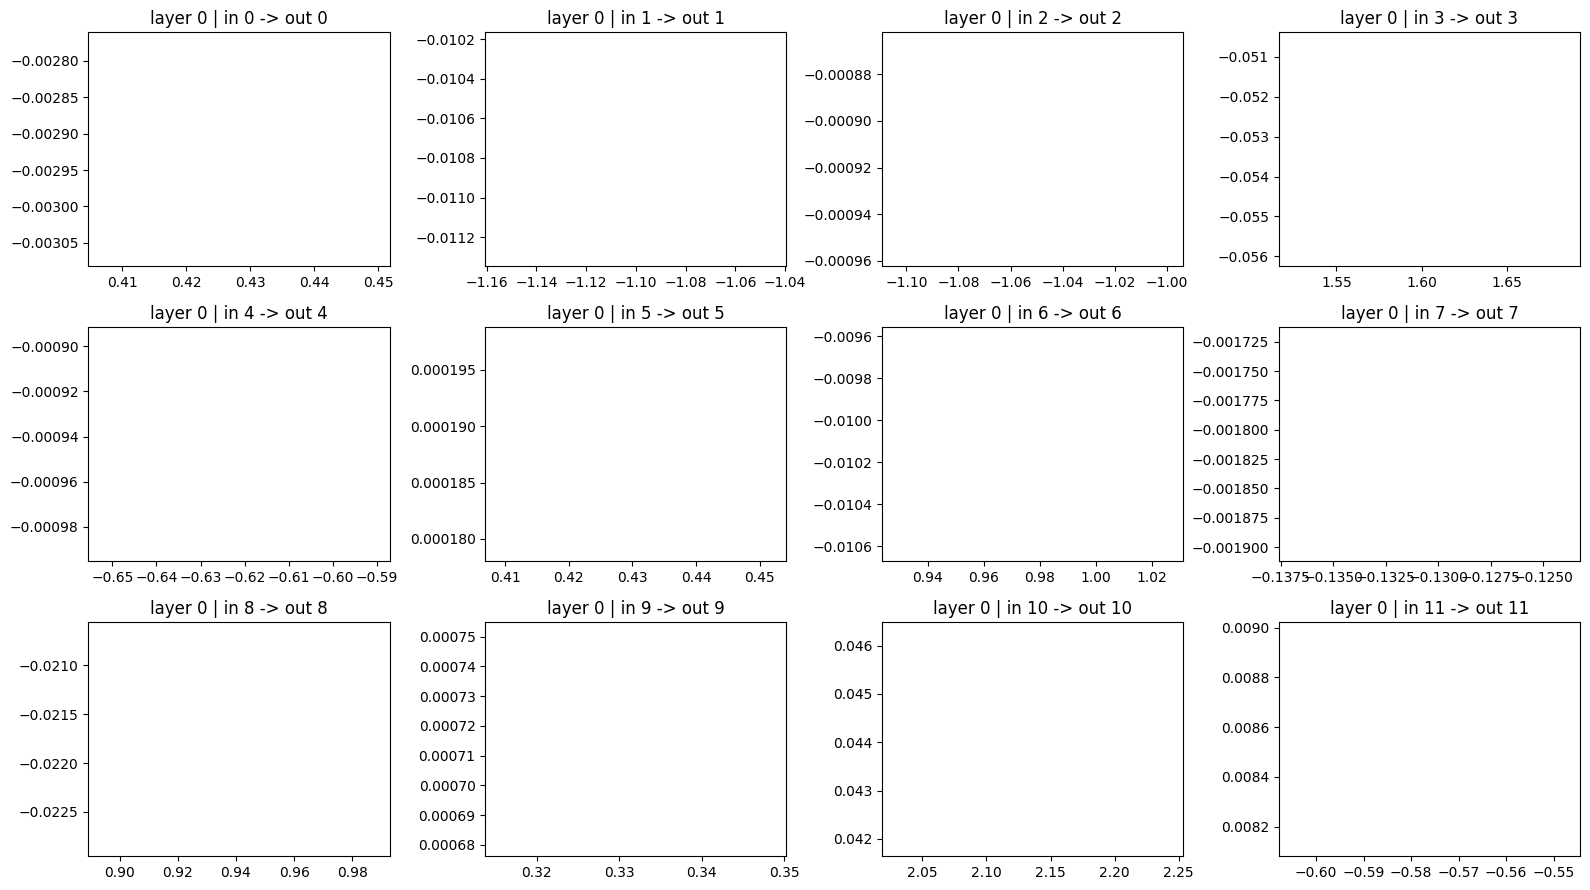

In [13]:
# Plot del KAN (opcional)
# El plot completo puede consumir MUCHA memoria.
# Recomendado: usa 'light' o 'full' con sample=True.
PLOT_KAN = 'light'  # 'none' | 'light' | 'full'
MAX_LIGHT_EDGES = 12

if PLOT_KAN == 'none':
    print('PLOT_KAN=none (no se genera el plot)')
elif PLOT_KAN == 'full':
    try:
        if hasattr(kan, 'plot'):
            out_dir = ROOT / 'notebooks' / 'figures' / 'kan_full'
            out_dir.mkdir(parents=True, exist_ok=True)
            # sample=True reduce numero de splines renderizados
            kan.plot(folder=str(out_dir), sample=True, scale=0.25)
            print('KAN plot guardado en:', out_dir)
            import matplotlib.pyplot as plt
            plt.close('all')
        else:
            print('KAN plot() no disponible en esta version')
    except MemoryError as e:
        print('MemoryError en kan.plot():', e)
        print("Sugerencia: usa PLOT_KAN='light' o reduce scale")
else:
    # Plot ligero de unas pocas splines (sin guardar archivos)
    if getattr(kan, 'acts', None) is None or getattr(kan, 'spline_postacts', None) is None:
        with torch.no_grad():
            _ = kan(Xva_h[:WARMUP_N])

    try:
        import matplotlib.pyplot as plt
        l = 0  # primera capa
        # toma un subconjunto peque?o y estable
        pairs = [(i % kan.spline_postacts[l].shape[2], i % kan.spline_postacts[l].shape[1]) for i in range(MAX_LIGHT_EDGES)]
        n = len(pairs)
        cols = min(4, n)
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
        axes = np.array(axes).reshape(-1)
        for ax, (i,j) in zip(axes, pairs):
            x = kan.acts[l][:, i].cpu().detach().numpy()
            y = kan.spline_postacts[l][:, j, i].cpu().detach().numpy()
            ax.plot(x, y, lw=2)
            ax.set_title(f'layer {l} | in {i} -> out {j}')
        for ax in axes[len(pairs):]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('No se pudo generar el plot ligero:', e)


In [14]:
# Paso 5: formula simbolica
if hasattr(kan, "symbolic_enabled"):
    kan.symbolic_enabled = True
if hasattr(kan, "unfix_symbolic_all"):
    kan.unfix_symbolic_all()
if hasattr(kan, "auto_save"):
    kan.auto_save = False  # evita guardados repetidos durante auto_symbolic

# Usa ejemplos representativos para fijar splines antes de buscar la formula
X_sym = Xtr_h[:128].clone().detach()
with torch.no_grad():
    _ = kan(X_sym)

import inspect

def _call_with_optional_arg(fn, arg):
    try:
        sig = inspect.signature(fn)
    except Exception:
        sig = None
    if sig is None:
        return fn()
    params = list(sig.parameters.values()) 
    if len(params) == 0:
        return fn()
    return fn(arg)

if hasattr(kan, "auto_symbolic"):
    _call_with_optional_arg(kan.auto_symbolic, X_sym)
if hasattr(kan, "symbolic_formula"):
    print(kan.symbolic_formula())


RuntimeError: linspace only supports 0-dimensional start and end tensors, but got start with 1 dimension(s) and end with 1 dimension(s).